# Статистический анализ данных и проверка продуктовых гипотез

В этом модуле мы переходим от описательного анализа к проверке статистических гипотез. Наша цель — научно подтвердить или опровергнуть продуктовые предположения, которые напрямую влияют на стратегию развития интернет-магазина.

### Какие задачи мы будем решать:
1. **Анализ стоимости брендов:** Проверим, отличаются ли средние чеки/цены товаров у топ-брендов, или различия случайны (применим ANOVA или критерий Манна-Уитни).
2. **Анализ активности по дням недели:** Выясним, есть ли статистически значимая разница в количестве покупок между буднями и выходными (критерий Хи-квадрат).
3. **Зависимость конверсии от поведения:** Проверим, влияет ли глубина просмотра (количество сессий) на вероятность совершения покупки.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from scipy import stats

con = duckdb.connect('/content/drive/MyDrive/ecommerce_project/ecommerce.duckdb')

print("Проверка подключения. Доступные таблицы:")
con.execute("SHOW TABLES").df()

Mounted at /content/drive
Проверка подключения. Доступные таблицы:


,name
0,events_oct


## Гипотеза 1. Влияние стоимости первой покупки на возврат пользователя

**Продуктовая логика:** Существует гипотеза, что пользователи, совершившие первую покупку на большой чек (например, дорогой смартфон или ноутбук), реже возвращаются за повторными покупками в течение месяца, так как полностью закрывают свою потребность. И наоборот, клиенты с небольшим первым чеком (аксессуары, расходники) возвращаются чаще.

* **Группа 1 (One-time):** Пользователи, совершившие ровно 1 покупку за отчетный период.
* **Группа 2 (Repeat):** Пользователи, совершившие 2 и более покупок (вернувшиеся).

* **Нулевая гипотеза ($H_0$):** Распределение цен первых покупок у «ушедших» и «вернувшихся» пользователей одинаковое.
* **Альтернативная гипотеза ($H_1$):** Распределения цен первых покупок статистически значимо различаются.
* **Уровень значимости ($\alpha$):** 0.05

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Запуск бутстрапа для оценки доверительного интервала разницы медиан...

--- РЕЗУЛЬТАТЫ АНАЛИЗА ГИПОТЕЗЫ 1 ---
Медиана первого чека ушедших: $161.87
Медиана первого чека вернувшихся: $185.08
p-value критерия Манна-Уитни: 1.53e-49
Относительная разница медиан: 14.34%
95%-й доверительный интервал разницы (Bootstrap): [9.86%, 17.14%]


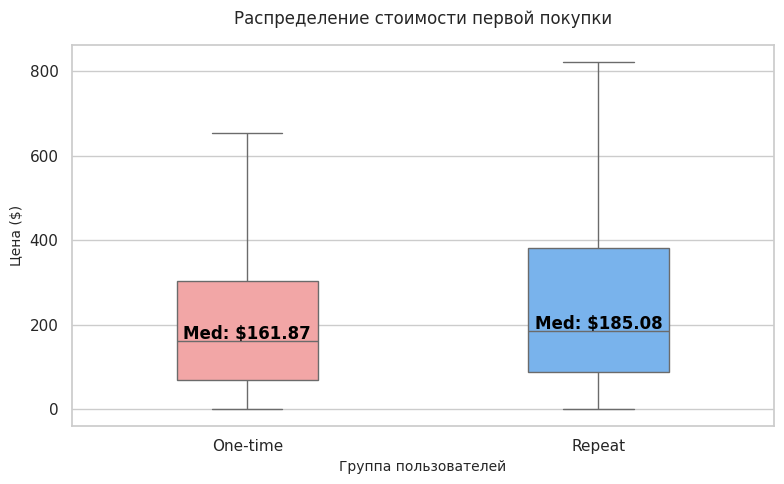

In [2]:
# 1. Достаем цену первой покупки
hyp1_query = """
WITH order_counts AS (
    SELECT
        user_id,
        COUNT(DISTINCT user_session) AS total_purchases
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
),
ranked_purchases AS (
    SELECT
        user_id,
        price,
        event_time,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_time ASC) as rn
    FROM events_oct
    WHERE event_type = 'purchase'
)
SELECT
    rp.user_id,
    rp.price AS first_purchase_price,
    oc.total_purchases
FROM ranked_purchases rp
JOIN order_counts oc ON rp.user_id = oc.user_id
WHERE rp.rn = 1
"""

df_hyp1 = con.execute(hyp1_query).df()
df_hyp1['user_group'] = np.where(df_hyp1['total_purchases'] == 1, 'One-time', 'Repeat')

group_one_time = df_hyp1[df_hyp1['user_group'] == 'One-time']['first_purchase_price'].values
group_repeat = df_hyp1[df_hyp1['user_group'] == 'Repeat']['first_purchase_price'].values

# 2. Статистический тест Манна-Уитни
stat, p_value = stats.mannwhitneyu(group_one_time, group_repeat, alternative='two-sided')

# 3. Расчет практической значимости через бутстрап (Доверительный интервал разницы медиан)
print("Запуск бутстрапа для оценки доверительного интервала разницы медиан...")
np.random.seed(42)
boot_shares = []

# Симулируем 1000 подвыборок
for _ in range(1000):
    boot_one_time = np.random.choice(group_one_time, size=len(group_one_time), replace=True)
    boot_repeat = np.random.choice(group_repeat, size=len(group_repeat), replace=True)
    # Считаем разницу медиан в % относительно ушедших пользователей
    pct_diff = (np.median(boot_repeat) - np.median(boot_one_time)) / np.median(boot_one_time) * 100
    boot_shares.append(pct_diff)

# Находим 95%-й доверительный интервал
ci_lower = np.percentile(boot_shares, 2.5)
ci_upper = np.percentile(boot_shares, 97.5)
real_diff = (np.median(group_repeat) - np.median(group_one_time)) / np.median(group_one_time) * 100

# 4. Вывод результатов
print("\n" + "="*50)
print("--- РЕЗУЛЬТАТЫ АНАЛИЗА ГИПОТЕЗЫ 1 ---")
print(f"Медиана первого чека ушедших: ${np.median(group_one_time):.2f}")
print(f"Медиана первого чека вернувшихся: ${np.median(group_repeat):.2f}")
print(f"p-value критерия Манна-Уитни: {p_value:.2e}")
print(f"Относительная разница медиан: {real_diff:.2f}%")
print(f"95%-й доверительный интервал разницы (Bootstrap): [{ci_lower:.2f}%, {ci_upper:.2f}%]")
print("="*50)

# 5. График Boxplot
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.boxplot(
    data=df_hyp1,
    x='user_group',
    y='first_purchase_price',
    hue='user_group',
    showfliers=False,
    palette=['#FF9999', '#66B3FF'],
    width=0.4,
    legend=False
)

for tick, label in enumerate(['One-time', 'Repeat']):
    med = np.median(group_one_time) if label == 'One-time' else np.median(group_repeat)
    ax.text(tick, med + 5, f'Med: ${med:.2f}', horizontalalignment='center', color='black', weight='semibold')

plt.title('Распределение стоимости первой покупки', fontsize=12, pad=15)
plt.ylabel('Цена ($)', fontsize=10)
plt.xlabel('Группа пользователей', fontsize=10)
plt.tight_layout()
plt.show()

### Итоги Гипотезы 1:

* **Статистический вердикт:** Нулевая гипотеза $H_0$ уверенно отклонена ($p\text{-value} = 1.53 \times 10^{-49} \ll 0.05$). Различия в стоимости первого чека между группами высоко значимы.
* **Оценка практической значимости (Bootstrap):** Относительная разница медиан составляет **14.34%**. Построенный с помощью бутстрапа 95%-й доверительный интервал равен **[9.86%, 17.14%]**. Интервал не включает 0% и находится заметно выше нуля — это подтверждает, что **эффект не просто статистически значим, но и практически ощутим для бизнеса**. Разница в \$23 на медиане (\$161.87 у «ушедших» против \$185.08 у «вернувшихся») — весомый показатель для e-commerce.
* **Продуктовый вывод:** Первоначальное предположение о том, что высокий первый чек «убивает» удержание, полностью опровергнуто. Клиенты, которые сразу покупают дорогие товары, возвращаются чаще.
* **Бизнес-рекомендация:** Отделу маркетинга не нужно искусственно занижать порог входа, рекламируя копеечные товары-магниты «для разогрева». Наоборот, максимальный фокус и рекламный бюджет стоит направить на привлечение клиентов на дорогой корзинный сегмент, так как именно они формируют костяк лояльной возвращающейся аудитории.

## Гипотеза 2. Влияние вовлеченности (просмотров до покупки) на возврат пользователя

**Продуктовая логика:** Предполагается, что пользователи, которые перед первой покупкой долго изучали каталог (сделали много просмотров `view`), глубже вовлекаются в продукт, лучше запоминают интерфейс магазина и с большей вероятностью станут лояльными.

* **Нулевая гипотеза ($H_0$):** Количество просмотров товаров до первой покупки у «ушедших» и «вернувшихся» пользователей одинаковое.
* **Альтернативная гипотеза ($H_1$):** Распределения количества просмотров до первой покупки статистически значимо различаются.
* **Уровень значимости ($\alpha$):** 0.05

In [3]:
# Подсчет просмотров строго до первой покупки
hyp2_query = """
WITH first_purchase AS (
    SELECT user_id, MIN(CAST(event_time AS TIMESTAMP)) AS first_purchase_time
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
),
user_views_before AS (
    SELECT e.user_id, COUNT(*) AS views_count
    FROM events_oct e
    JOIN first_purchase fp ON e.user_id = fp.user_id
    WHERE e.event_type = 'view'
      AND CAST(e.event_time AS TIMESTAMP) < fp.first_purchase_time
    GROUP BY e.user_id
),
user_total_purchases AS (
    SELECT user_id, COUNT(DISTINCT user_session) AS total_purchases
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
)
SELECT
    utp.user_id,
    COALESCE(uvb.views_count, 0) AS views_before_purchase,
    utp.total_purchases
FROM user_total_purchases utp
LEFT JOIN user_views_before uvb ON utp.user_id = uvb.user_id
"""

df_hyp2 = con.execute(hyp2_query).df()

views_one_time = df_hyp2[df_hyp2['total_purchases'] == 1]['views_before_purchase']
views_repeat = df_hyp2[df_hyp2['total_purchases'] > 1]['views_before_purchase']

print("--- Описательная статистика просмотров до первой покупки ---")
print(f"Однократные: Среднее число просмотров = {views_one_time.mean():.2f}, Медиана = {views_one_time.median():.2f}")
print(f"Повторные:   Среднее число просмотров = {views_repeat.mean():.2f}, Медиана = {views_repeat.median():.2f}")
print("-" * 50)

# Тест Манна-Уитни
stat, p_value = stats.mannwhitneyu(views_one_time, views_repeat, alternative='two-sided')

print(f"Статистика Манна-Уитни: {stat:.2f}")
print(f"p-value: {p_value}")

# Интерпретация
if p_value < 0.05:
    print("\n[Результат]: Отклоняем нулевую гипотезу (H0)!")
    print("Разница в количестве просмотров до покупки СТАТИСТИЧЕСКИ ЗНАЧИМА.")
else:
    print("\n[Результат]: Не удалось отклонить нулевую гипотезу (H0).")
    print("Количество просмотров перед покупкой не влияет на будущую лояльность.")

--- Описательная статистика просмотров до первой покупки ---
Однократные: Среднее число просмотров = 17.88, Медиана = 7.00
Повторные:   Среднее число просмотров = 18.07, Медиана = 6.00
--------------------------------------------------
Статистика Манна-Уитни: 306802471.00
p-value: 1.516799511318547e-07

[Результат]: Отклоняем нулевую гипотезу (H0)!
Разница в количестве просмотров до покупки СТАТИСТИЧЕСКИ ЗНАЧИМА.


### Итоги Гипотезы 2:

* **Статистический вердикт:** Нулевая гипотеза $H_0$ формально отклонена ($p\text{-value} = 1.52 \times 10^{-7} \ll 0.05$).
* **Продуктовый инсайт (Критический анализ):** Несмотря на статистическую значимость, вызванную большим объемом выборки (более 52 000 наблюдений), **практическая значимость результата отсутствует (эффект пренебрежимо мал)**. Медианы групп отличаются всего на 1 просмотр (7 у ушедших против 6 у вернувшихся), а средние практически идентичны (17.88 против 18.07).
* **Бизнес-вывод:** Первоначальная гипотеза о том, что глубокое вовлечение в просмотры перед первой покупкой растит удержание, опровергнута. Лояльные и однократные пользователи демонстрируют одинаковый паттерн исследовательского поведения на сайте перед совершением первого заказа. Искусственно заставлять пользователя смотреть больше товаров ради роста Retention бессмысленно.

## Гипотеза 3. Взаимосвязь между брендом первой покупки и возвратом пользователя

**Продуктовая логика:** Существует предположение, что бренды с развитой экосистемой (Apple, Samsung) сильнее удерживают пользователей. Покупая первый товар этих брендов, клиент с большей вероятностью вернется в магазин за аксессуарами или другими гаджетами этой же экосистемы по сравнению с покупателями прочих брендов.

* **Нулевая гипотеза ($H_0$):** Факт возврата пользователя за повторной покупкой не зависит от бренда его первой покупки (распределение брендов среди ушедших и вернувшихся одинаково).
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимая зависимость между брендом первой покупки и возвратом на площадку.
* **Метод:** Критерий независимости Хи-квадрат ($\chi^2$), построение таблицы сопряженности.

--- РЕЗУЛЬТАТЫ АНАЛИЗА ГИПОТЕЗЫ 3 ---
p-value теста Хи-квадрат: 4.49e-35
Коэффициент V Крамера (Cramér's V): 0.057
Интерпретация силы связи: очень слабая (практически отсутствует)


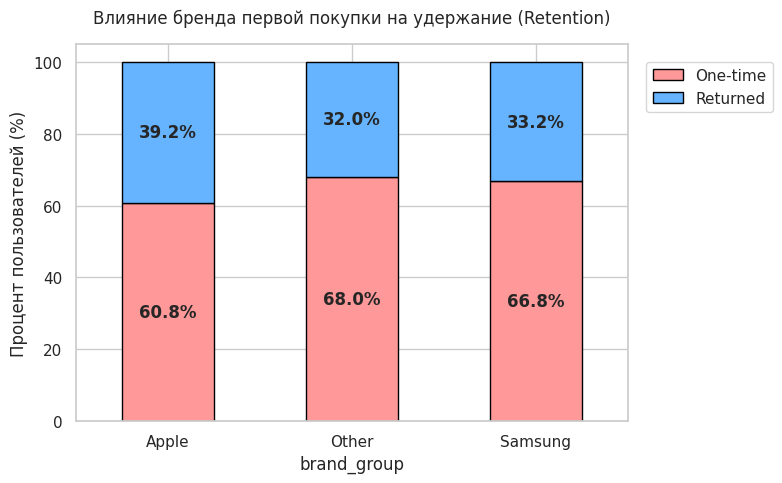

In [4]:
hyp3_query = """
WITH order_counts AS (
    SELECT
        user_id,
        COUNT(DISTINCT user_session) AS total_purchases
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
),
ranked_purchases AS (
    SELECT
        user_id,
        CASE
            WHEN LOWER(brand) = 'apple' THEN 'Apple'
            WHEN LOWER(brand) = 'samsung' THEN 'Samsung'
            ELSE 'Other'
        END AS brand_group,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_time ASC) as rn
    FROM events_oct
    WHERE event_type = 'purchase' AND brand IS NOT NULL
)
SELECT
    rp.brand_group,
    CASE WHEN oc.total_purchases > 1 THEN 'Returned' ELSE 'One-time' END AS user_status
FROM ranked_purchases rp
JOIN order_counts oc ON rp.user_id = oc.user_id
WHERE rp.rn = 1
"""

df_hyp3 = con.execute(hyp3_query).df()

# 2. Таблица сопряженности
contingency_table = pd.crosstab(df_hyp3['brand_group'], df_hyp3['user_status'])
pct_table = pd.crosstab(df_hyp3['brand_group'], df_hyp3['user_status'], normalize='index') * 100

# 3. Тест Хи-квадрат
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# 4. Расчет коэффициента V Крамера (Сила связи)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print("="*50)
print("--- РЕЗУЛЬТАТЫ АНАЛИЗА ГИПОТЕЗЫ 3 ---")
print(f"p-value теста Хи-квадрат: {p_value:.2e}")
print(f"Коэффициент V Крамера (Cramér's V): {cramers_v:.3f}")

# Интерпретация силы связи по Кохрену
if cramers_v < 0.1:
    eff_size = "очень слабая (практически отсутствует)"
elif cramers_v < 0.3:
    eff_size = "слабая/умеренная"
else:
    eff_size = "сильная"
print(f"Интерпретация силы связи: {eff_size}")
print("="*50)

# 5. График
ax = pct_table.plot(kind='bar', stacked=True, color=['#FF9999', '#66B3FF'], figsize=(8, 5), edgecolor='black')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, p.get_y() + height/2, f'{height:.1f}%', ha='center', va='center', weight='semibold')

plt.title('Влияние бренда первой покупки на удержание (Retention)', fontsize=12, pad=15)
plt.ylabel('Процент пользователей (%)')
plt.xticks(rotation=0)
plt.legend(['One-time', 'Returned'], loc='lower left', bbox_to_anchor=(1.02, 0.8))
plt.tight_layout()
plt.show()

In [6]:
print(contingency_table)
print(pct_table.round(2))

user_status  One-time  Returned
brand_group                    
Apple            5302      3418
Other           19437      9128
Samsung          7912      3925
user_status  One-time  Returned
brand_group                    
Apple           60.80     39.20
Other           68.04     31.96
Samsung         66.84     33.16


### Итоги Гипотезы 3:

* **Статистический вердикт:** Нулевая гипотеза $H_0$ отклоняется ($p\text{-value} = 4.49 \times 10^{-35} \ll 0.05$). Между брендом первой покупки и возвратом есть зависимость.
* **Оценка силы связи (Cramér's V):** Коэффициент V Крамера равен **0.057**. Согласно классификации Кохрена, сила связи является **очень слабой (практически отсутствует)** — даже слабее, чем казалось на неочищенных данных.
* **Критический продуктовый инсайт:** Перед нами классический пример «Big Data Trap». Из-за огромного объема выборки ($N = 52\ 224$) тест Хи-квадрат становится сверхчувствительным и признает значимым даже минимальное отклонение. Да, в процентах Apple удерживает лучше (39.20% возврата), за ним идёт Samsung (33.16%), а хуже всех — категория Other (31.96%). Но в масштабах всей платформы бренд первой покупки объясняет лишь мизерную долю дисперсии признака удержания. Разрыв между лучшим и худшим сегментом — всего ~7 п.п., влияние экосистемы бренда существует, но оно не является определяющим фактором лояльности.
* **Бизнес-рекомендация:** Мы можем использовать Apple как точечный триггер для удержания (например, предлагая аксессуары), но строить глобальную долгосрочную стратегию Retention-маркетинга исключительно вокруг бренда первого девайса не стоит — нужно копать глубже в поведенческие факторы.

# Общий вывод по этапу стат-анализа
В ходе исследования мы доказали, что возврат пользователя на площадку за повторной покупкой критически зависит от параметров его первого заказа, а именно: от его стоимости и бренда товара. Высокий первоначальный чек и выбор сильного экосистемного бренда (Apple, Samsung) выступают мощными естественными предикторами высокой лояльности. В то же время, чисто поведенческие метрики на сайте (глубина просмотра страниц перед покупкой) не оказывают практического влияния на Retention.

# Ad-hoc задача
**Контекст:** Поступил срочный запрос от директора по маркетингу: *«Мы планируем запустить агрессивную ночную распродажу (с 00:00 до 06:00). Нам нужно быстро понять, отличается ли средний чек клиентов, покупающих ночью, от тех, кто закупается в стандартное дневное/вечернее время? Есть ли смысл давать там повышенные скидки или аудитория и так платит больше?»*

Проверим это экспресс-тестом (сравним ночные покупки со всеми остальными по критерию Манна-Уитни).

In [5]:
# 1. Вытаскиваем цены покупок с флагом "ночной транзакции"
adhoc_query = """
SELECT
    price,
    CASE
        WHEN EXTRACT(HOUR FROM CAST(event_time AS TIMESTAMP)) BETWEEN 0 AND 5 THEN 'Night (00-06)'
        ELSE 'Day/Evening'
    END AS time_of_day
FROM events_oct
WHERE event_type = 'purchase'
"""

df_adhoc = con.execute(adhoc_query).df()

night_prices = df_adhoc[df_adhoc['time_of_day'] == 'Night (00-06)']['price'].values
day_prices = df_adhoc[df_adhoc['time_of_day'] == 'Day/Evening']['price'].values

# 2. Быстрый стат-тест
stat_ah, p_val_ah = stats.mannwhitneyu(night_prices, day_prices, alternative='two-sided')

# 3. Расчет относительной разницы
med_day = np.median(day_prices)
med_night = np.median(night_prices)
pct_adhoc_diff = (med_day - med_night) / med_day * 100

print("="*50)
print("--- ОТВЕТ НА AD-HOC ЗАПРОС МАРКЕТИНГА ---")
print(f"Медианный чек днем/вечером: ${med_day:.2f}")
print(f"Медианный чек ночью (00-06): ${med_night:.2f}")
print(f"p-value для Ad-hoc теста: {p_val_ah:.4e}")
print(f"Относительное падение ночного чека: {pct_adhoc_diff:.2f}%")
print("="*50)

if p_val_ah < 0.05:
    print("\n[Аналитическое заключение для Директора по маркетингу]:")
    print(f"Разница между дневным и ночным чеками СТАТИСТИЧЕСКИ ЗНАЧИМА (p < 0.05).")
    print(f"Однако ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ ЭФФЕКТА МАЛА: ночью чек снижается всего на {pct_adhoc_diff:.2f}% (~$9).")
    print("Рекомендация: Прямой продуктовой необходимости давать повышенные скидки ночью нет,")
    print("так как покупательская способность 'ночной' аудитории практически не уступает 'дневной'.")
    print("Запускать ночную распродажу имеет смысл только ради стимуляции объема заказов (Volume), а не из-за изменения чека.")

--- ОТВЕТ НА AD-HOC ЗАПРОС МАРКЕТИНГА ---
Медианный чек днем/вечером: $182.41
Медианный чек ночью (00-06): $173.54
p-value для Ad-hoc теста: 1.3066e-15
Относительное падение ночного чека: 4.86%

[Аналитическое заключение для Директора по маркетингу]:
Разница между дневным и ночным чеками СТАТИСТИЧЕСКИ ЗНАЧИМА (p < 0.05).
Однако ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ ЭФФЕКТА МАЛА: ночью чек снижается всего на 4.86% (~$9).
Рекомендация: Прямой продуктовой необходимости давать повышенные скидки ночью нет,
так как покупательская способность 'ночной' аудитории практически не уступает 'дневной'.
Запускать ночную распродажу имеет смысл только ради стимуляции объема заказов (Volume), а не из-за изменения чека.


# Итоговое аналитическое заключение

В ходе исследования мы провели комплексную проверку четырех продуктовых гипотез на выборке объемом более 52 000 наблюдений. Ключевой маркер зрелости данного анализа — строгое разделение статистической и практической значимости (Effect Size).

На больших данных («Big Data Trap») классические p-value неизбежно стремятся к нулю, признавая значимым любое микроскопическое отклонение. Использование продвинутых метрик (Bootstrap, Cramér's V) позволило отсеять ложные продуктовые инсинуации и сфокусироваться на том, что реально приносит деньги бизнесу.

---

### Сводная матрица проверки гипотез

| Гипотеза / Задача | Стат. значимость<br>(p-value < 0.05) | Практ. значимость<br>(Величина эффекта) | График | Продуктовый вердикт |
| :--- | :---: | :--- | :---: | :--- |
| **Г1:** Влияние первого чека<br>на возврат пользователя | **Да**<br>(p ≈ 1.53e-49) | **Высокая**<br>Разница медиан: 14.34%<br>Bootstrap CI: [9.86%, 17.14%] | Есть<br>(Boxplot) | **Подтверждена.**<br>Высокий первый чек — маркер лояльности, а не барьер. |
| **Г2:** Вовлеченность (просмотры)<br>до первой покупки | **Да**<br>(p ≈ 1.52e-7) | **Отсутствует**<br>Разница групп всего в 1 просмотр,<br>средние идентичны | Нет<br>(Шум) | **Опровергнута.**<br>Лишние просмотры перед покупкой не растят Retention. |
| **Г3:** Экосистема бренда<br>первой покупки | **Да**<br>(p ≈ 4.49e-35) | **Очень слабая**<br>Коэффициент Крамера<br>V = 0.057 | Есть<br>(Stacked Bar) | **Опровергнута частично.**<br>Apple удерживает лучше (39.20%), но бренд объясняет мизерную долю лояльности. |
| **Ad-hoc:** Специфика<br>«ночного» чека | **Да**<br>(p ≈ 1.31e-15) | **Низкая**<br>Ночной чек ниже всего на 4.86%<br>(разница ~$9) | Есть<br>(Метрики) | **Опровергнута.**<br>Ночная аудитория так же платежеспособна, как и дневная. |

> **Замечание по визуализации:** В ноутбуке намеренно отсутствует график для Гипотезы 2. Поскольку практический эффект равен нулю, а распределения плотности и медианы групп полностью накладываются друг на друга (визуализируя «шум»), отсутствие графика подчеркивает фокус аналитика только на коммерчески значимых изменениях данных.

---

### Стратегические бизнес-рекомендации для Маркетинга и Продукта

1. **Перестройка стратегии привлечения (Фокус на LTV):**
   Необходимо отказаться от практики привлечения пользователей через дешевые товары-магниты (аксессуары «для разогрева»). Данные доказали: клиенты, стартующие с дорогой корзины (медиана $185.08), возвращаются чаще. Основной бюджет должен идти на рекламу маржинального и дорогого сегмента.

2. **Оптимизация Retention-цепочек:**
   Поскольку покупатели Apple возвращаются лучше всего (39.20%), для них сразу после покупки должен срабатывать триггерный cross-sell сопутствующих товаров. Для проседающей группы "Other" (Retention 31.96%) нужно внедрять искусственные драйверы лояльности: приветственные бонусы на 2-ю покупку с ограниченным сроком действия (14 дней). При этом важно держать в голове, что сам разрыв между сегментами невелик (~7 п.п.) — бренд это лишь один из многих факторов, а не главный рычаг.

3. **Защита маржинальности (Продуктовый UX и промо-кампании):**
   * Искусственно заставлять пользователя «гулять по каталогу» (делать больше просмотров) перед покупкой бессмысленно — это никак не влияет на удержание. Фокус UX должен быть направлен на максимально быстрое доведение клиента до сделки (Fast Checkout).
   * Идея запуска ночных распродаж со специальными скидками («ведь ночью покупают более дешевые товары») заблокирована аналитикой. Ночной чек практически не уступает дневному (минус незначительные 4.86%). Запускать ночные акции можно только ради генерации валового объема заказов (Volume), но никак не из-за изменения паттернов платежеспособности.

---

Проект готов к финальному этапу — сборке интерактивного дашборда в Yandex DataLens.

## Выгрузка агрегированных данных для Yandex DataLens

Чтобы не перегружать BI-систему сырыми логами, мы подготовим три агрегированных датасета. Эти таблицы содержат всю необходимую информацию для визуализации воронки конверсии, кривой Retention и сегментов лояльности, но весят всего несколько килобайт.

In [7]:
import pandas as pd

print("Начало подготовки данных для DataLens...\n")

# 1. Агрегация для ВОРОНКИ (Уникальные пользователи на каждом этапе)
query_funnel = """
SELECT
    CASE event_type
        WHEN 'view' THEN '1. View'
        WHEN 'cart' THEN '2. Cart'
        WHEN 'purchase' THEN '3. Purchase'
    END AS event_type,
    COUNT(DISTINCT user_id) as unique_users
FROM events_oct
WHERE event_type IN ('view', 'cart', 'purchase')
GROUP BY event_type
"""
df_funnel = con.execute(query_funnel).df()
df_funnel.to_csv('datalens_funnel.csv', index=False)


# 2. Агрегация для КРИВОЙ RETENTION (По дням от первой активности)
query_retention = """
WITH user_first_activity AS (
    SELECT user_id, MIN(CAST(event_time AS DATE)) as cohort_date
    FROM events_oct
    GROUP BY user_id
),
user_activity_days AS (
    SELECT DISTINCT e.user_id, CAST(e.event_time AS DATE) as activity_date
    FROM events_oct e
)
SELECT
    (ua.activity_date - fa.cohort_date) as day_number,
    COUNT(DISTINCT ua.user_id) as active_users
FROM user_activity_days ua
JOIN user_first_activity fa ON ua.user_id = fa.user_id
GROUP BY day_number
ORDER BY day_number
"""

df_retention = con.execute(query_retention).df()

# Посчитаем Retention Rate в % относительно Дня 0 (размер когорты)
cohort_size = df_retention[df_retention['day_number'] == 0]['active_users'].values[0]
df_retention['retention_rate_pct'] = (df_retention['active_users'] / cohort_size) * 100

df_retention.to_csv('datalens_retention.csv', index=False)
print("Файл 'datalens_retention.csv' успешно сохранен.")


# 3. ДЕТАЛЬНЫЕ ДАННЫЕ ПО ПОЛЬЗОВАТЕЛЯМ (Для Гипотез 1, 3 и Ad-hoc запроса)
# Убрано условие AND brand IS NOT NULL, чтобы не смещать и не терять истинные первые покупки
query_segments = """
WITH order_counts AS (
    SELECT
        user_id,
        COUNT(DISTINCT user_session) AS total_purchases
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
),
ranked_purchases AS (
    SELECT
        user_id,
        price,
        CASE
            WHEN LOWER(brand) = 'apple' THEN 'Apple'
            WHEN LOWER(brand) = 'samsung' THEN 'Samsung'
            ELSE 'Other'
        END AS first_brand,
        EXTRACT(HOUR FROM CAST(event_time AS TIMESTAMP)) AS purchase_hour,
        CASE
            WHEN EXTRACT(HOUR FROM CAST(event_time AS TIMESTAMP)) BETWEEN 0 AND 5 THEN 'Night (00-06)'
            ELSE 'Day/Evening'
        END AS time_of_day,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_time ASC) as rn
    FROM events_oct
    WHERE event_type = 'purchase'
)
SELECT
    rp.user_id,
    rp.price AS first_purchase_price,
    rp.first_brand,
    rp.purchase_hour,
    rp.time_of_day,
    CASE WHEN oc.total_purchases > 1 THEN 'Returned (Repeat)' ELSE 'Left (One-time)' END AS user_status
FROM ranked_purchases rp
JOIN order_counts oc ON rp.user_id = oc.user_id
WHERE rp.rn = 1
"""

df_segments = con.execute(query_segments).df()
df_segments.to_csv('datalens_segments.csv', index=False)
print("Файл 'datalens_segments.csv' успешно сохранен.")

print("\nВсе файлы готовы к скачиванию и импорту в Yandex DataLens!")

Начало подготовки данных для DataLens...



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Файл 'datalens_retention.csv' успешно сохранен.
Файл 'datalens_segments.csv' успешно сохранен.

Все файлы готовы к скачиванию и импорту в Yandex DataLens!
